In [3]:
import os
import csv
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from aijack.collaborative import FedAVGClient, FedAVGServer, FedAVGAPI

print("Python:",)
print("Torch:", torch.__version__)
print("Device available:", "cuda" if torch.cuda.is_available() else "cpu")


Python:
Torch: 2.9.1
Device available: cpu


In [5]:
import inspect
print("FedAVGAPI:", inspect.signature(FedAVGAPI))
print("FedAVGClient:", inspect.signature(FedAVGClient))
print("FedAVGServer:", inspect.signature(FedAVGServer))


FedAVGAPI: (server, clients, criterion, local_optimizers, local_dataloaders, num_communication=1, local_epoch=1, use_gradients=True, custom_action=<function FedAVGAPI.<lambda> at 0x14a867760>, device='cpu')
FedAVGClient: (model, user_id=0, lr=0.1, send_gradient=True, optimizer_type_for_global_grad='sgd', server_side_update=True, optimizer_kwargs_for_global_grad={}, device='cpu')
FedAVGServer: (clients, global_model, server_id=0, lr=0.1, optimizer_type='sgd', server_side_update=True, optimizer_kwargs={}, device='cpu')


In [6]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


In [8]:
def iid_partition(dataset_size: int, num_clients: int, seed: int = 42) -> List[List[int]]:
    rng = np.random.default_rng(seed)
    indices = np.arange(dataset_size)
    rng.shuffle(indices)
    splits = np.array_split(indices, num_clients)
    return [split.tolist() for split in splits]


In [9]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: str) -> Tuple[float, float]:
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total, correct = 0, 0
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        running_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return running_loss / max(total, 1), correct / max(total, 1)


In [10]:
@dataclass
class Config:
    seed: int = 42
    device: str = "cpu"   # change to "cuda" if available
    num_clients: int = 5
    batch_size: int = 64
    lr: float = 0.01
    local_epoch: int = 1
    num_rounds: int = 5

    data_dir: str = "./data"
    out_dir: str = "./results/baseline"

cfg = Config(
    seed=42,
    device="cuda" if torch.cuda.is_available() else "cpu",
    num_clients=5,
    batch_size=64,
    lr=0.01,
    local_epoch=1,
    num_rounds=5
)

cfg


Config(seed=42, device='cpu', num_clients=5, batch_size=64, lr=0.01, local_epoch=1, num_rounds=5, data_dir='./data', out_dir='./results/baseline')

In [11]:
set_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True)

transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(cfg.data_dir, train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(cfg.data_dir, train=False, download=True, transform=transform)

client_indices = iid_partition(len(train_ds), cfg.num_clients, seed=cfg.seed)

local_dataloaders = []
for idxs in client_indices:
    subset = Subset(train_ds, idxs)
    loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
    local_dataloaders.append(loader)

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

len(local_dataloaders), len(train_ds), len(test_ds)


(5, 60000, 10000)

In [12]:
clients = []
local_optimizers = []

for i in range(cfg.num_clients):
    model = SimpleCNN().to(cfg.device)
    client = FedAVGClient(model=model, user_id=i, lr=cfg.lr, device=cfg.device)
    clients.append(client)

    opt = optim.SGD(model.parameters(), lr=cfg.lr)
    local_optimizers.append(opt)

global_model = SimpleCNN().to(cfg.device)
server = FedAVGServer(clients=clients, global_model=global_model, lr=cfg.lr, device=cfg.device)

criterion = nn.CrossEntropyLoss()

api = FedAVGAPI(
    server,
    clients,
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=cfg.num_rounds,
    local_epoch=cfg.local_epoch,
    device=cfg.device,
)

print("Setup OK")


Setup OK


In [13]:
loss0, acc0 = evaluate(global_model, test_loader, cfg.device)
print(f"[Round 0] loss={loss0:.4f} acc={acc0:.4f}")


[Round 0] loss=2.3042 acc=0.0838


In [14]:
api.run()
print("Federated training finished.")


Federated training finished.


In [15]:
lossf, accf = evaluate(global_model, test_loader, cfg.device)
print(f"[Final] loss={lossf:.4f} acc={accf:.4f}")


[Final] loss=0.3051 acc=0.9119


In [16]:
metrics_path = os.path.join(cfg.out_dir, "metrics.csv")
with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["round", "test_loss", "test_acc"])
    writer.writerow([0, loss0, acc0])
    writer.writerow([cfg.num_rounds, lossf, accf])

metrics_path


'./results/baseline/metrics.csv'

In [18]:
import pandas as pd

metrics_path = "./results/baseline/metrics.csv"
df = pd.read_csv(metrics_path)
df



,round,test_loss,test_acc
0,0,2.304155,0.0838
1,5,0.305076,0.9119


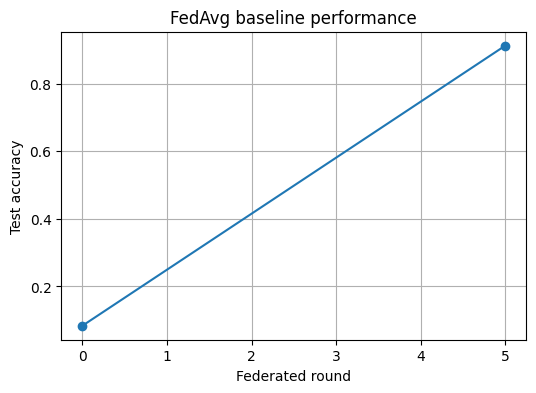

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df["round"], df["test_acc"], marker="o")
plt.xlabel("Federated round")
plt.ylabel("Test accuracy")
plt.title("FedAvg baseline performance")
plt.grid(True)
plt.show()


In [33]:
from aijack.attack.inversion import GradientInversionAttackServerManager
import inspect

print("Manager signature:", inspect.signature(GradientInversionAttackServerManager))


Manager signature: (*args, **kwargs)


In [34]:
AttackFedAVGServer = manager.attach(FedAVGServer)


In [35]:
server = AttackFedAVGServer(
    clients,
    global_model,
    lr=cfg.lr,
    device=cfg.device
)


In [36]:
api = FedAVGAPI(
    server,
    clients,
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=1,
    local_epoch=1,
    use_gradients=True,
    device=cfg.device,
)

api.run()

print("attack_results present?", hasattr(server, "attack_results"))


TypeError: LBFGS.__init__() got an unexpected keyword argument 'gradinvattack_kwargs'